# BIST Blue-Chip Şirketlerinin Dolar ve Altına Duyarlılığı
### Veri Bilimi Dönem Projesi — Tek Dosyalık Analiz Notebook'u

Bu notebook veri biliminin tüm iş akışını **tek dosyada** içerir:
**veri yükleme → temizleme → keşifsel analiz (EDA) → görselleştirme → modelleme.**

**İnceleme evreni:** BIST30'da yer alan, işlem hacmi en yüksek 12 blue-chip (öncü) şirket.

**Araştırma soruları (analizden önce tanımlı, Bölüm 5'te yanıtlanır):**
- **AS-1:** Hangi sektörler dolara/altına daha duyarlı? (doğrusal regresyon)
- **AS-2:** Dolar şoku (aykırı) günlerinde hisseler nasıl ayrışır? (ihracatçı vs banka)
- **AS-3:** Dolar mı hisseyi, hisse mi doları önceller? (gecikmeli çapraz korelasyon)

> **Metodolojik not:** Analiz fiyat düzeyi üzerinde değil **günlük getiri** (yüzde değişim)
> üzerinde yürür; fiyat serileri durağan olmadığından doğrudan kullanımı sahte korelasyon
> (spurious correlation) üretir. Tüm getiriler **TL bazlıdır** (BIST hisseleri TL işlem görür).

## 0. Kütüphaneler

Gerekirse `yfinance` kurulur. Diğer kütüphaneler standart veri bilimi yığınıdır.

In [1]:
# yfinance kurulu değilse kur (Jupyter içinden pip çağrısı)
try:
    import yfinance as yf
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance", "-q"])
    import yfinance as yf

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Görselleştirme genel ayarları
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Veri Yükleme

Veriler **Yahoo Finance**'ten `yfinance` API'si ile çekilir: 12 BIST hissesi (`.IS` uzantılı),
USD/TRY kuru ve ons altın (USD). Şirketler farklı sektörleri temsil edecek şekilde,
BIST30 içinden işlem hacmi yüksek olanlardan seçilmiştir.

In [2]:
# --- Semboller ve meta bilgiler ---
# Her hisse için: (Yahoo sembolü) -> (kısa kod, sektör)
HISSE_META = {
    "THYAO.IS": ("THYAO", "Havacılık"),   "GARAN.IS": ("GARAN", "Bankacılık"),
    "AKBNK.IS": ("AKBNK", "Bankacılık"),  "ISCTR.IS": ("ISCTR", "Bankacılık"),
    "ASELS.IS": ("ASELS", "Savunma"),     "KCHOL.IS": ("KCHOL", "Holding"),
    "SAHOL.IS": ("SAHOL", "Holding"),     "EREGL.IS": ("EREGL", "Demir-Çelik"),
    "TUPRS.IS": ("TUPRS", "Enerji"),      "BIMAS.IS": ("BIMAS", "Perakende"),
    "SISE.IS":  ("SISE",  "Cam"),         "TCELL.IS": ("TCELL", "Telekom"),
}
# Makro seriler: (Yahoo sembolü) -> kısa ad
MAKRO_META = {"TRY=X": "USDTRY", "GC=F": "ALTIN"}  # USDTRY = 1 doların TL karşılığı; ALTIN = ons/USD

# Sektör sözlüğü (yorumlamada kullanılır)
SEKTOR = {kod: sek for (kod, sek) in HISSE_META.values()}
HISSELER = list(SEKTOR.keys())

BASLANGIC, BITIS = "2021-07-01", "2026-07-01"   # son ~5 yıl

In [3]:
def veri_indir(sembol):
    """Tek bir sembolün günlük OHLCV verisini indirir; kapanış (Close) serisini döndürür.
       auto_adjust=True -> fiyatlar temettü ve bölünmelere göre düzeltilir (aksi halde
       bölünme günleri sahte %50 düşüş gibi görünürdü)."""
    df = yf.download(sembol, start=BASLANGIC, end=BITIS, auto_adjust=True, progress=False)
    # yfinance bazen MultiIndex kolon döndürür; tek seviyeye indir
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df["Close"]

# Tüm hisseleri ve makro serileri indirip bir sözlükte topla
seri_sozluk = {}
for sembol, (kod, _) in HISSE_META.items():
    seri_sozluk[kod] = veri_indir(sembol)
for sembol, ad in MAKRO_META.items():
    seri_sozluk[ad] = veri_indir(sembol)

# Tüm serileri tarih indeksinde tek bir tabloda birleştir (dış birleştirme)
ham = pd.DataFrame(seri_sozluk)
print("Ham veri boyutu (birleştirmeden önce hizalanmış):", ham.shape)
ham.tail(3)

Ham veri boyutu (birleştirmeden önce hizalanmış): (1302, 14)


,THYAO,GARAN,AKBNK,ISCTR,ASELS,KCHOL,SAHOL,EREGL,TUPRS,BIMAS,SISE,TCELL,USDTRY,ALTIN
Date,,,,,,,,,,,,,,
2026-06-26,330.7500,138.4000,77.2500,14.7400,361.5000,198.2000,97.4500,42.1200,219.2000,374.5000,45.3200,110.9000,46.5793,"4,078.7000"
2026-06-29,329.0000,137.3000,77.2000,14.6900,357.5000,195.7000,97.5000,41.2000,219.3000,371.0000,44.9400,109.6000,46.6162,"4,022.3000"
2026-06-30,326.0000,138.0000,77.0000,14.8100,345.0000,193.5000,97.5000,40.4800,227.5000,365.2500,44.3000,107.4000,46.6407,"4,022.8999"


## 2. Veri Temizleme

Bu bölümde dört temizleme adımı uygulanır:
1. **Tip dönüşümü** — indeksin tarih tipinde, değerlerin sayısal olduğundan emin olma.
2. **Tarih hizalama + eksik veri** — BIST ile ABD piyasası tatilleri farklıdır; tarihleri
   BIST işlem günlerine hizalar, makro boşlukları bir önceki değerle (ffill) doldururuz.
3. **Türetme** — ons altını (USD) kur ile çarparak TL bazlı altın serisi üretme.
4. **Aykırı değer incelemesi** — uç getirileri z-skoru ile tespit etme (silmeden).

In [4]:
# --- Adım 1: Tip dönüşümü ---
ham.index = pd.to_datetime(ham.index)      # indeks -> tarih tipi
ham = ham.apply(pd.to_numeric, errors="coerce")  # tüm kolonlar -> sayısal (float)
print("Kolon tipleri tekil mi:", ham.dtypes.nunique() == 1, "| tip:", ham.dtypes.iloc[0])

Kolon tipleri tekil mi: True | tip: float64


In [5]:
# --- Adım 2: Tarih hizalama ve eksik veri ---
# Referans takvim: ilk hissenin işlem gördüğü günler (BIST takvimi)
bist_gunleri = ham[HISSELER[0]].dropna().index

# Sadece BIST işlem günlerini tut; makro serilerdeki (dolar/altın) boşlukları
# bir önceki günün değeriyle doldur (forward-fill) -> tatil farklarını giderir
fiyatlar = ham.loc[bist_gunleri].ffill()

# Serinin en başındaki (ffill ile doldurulamayan) olası boşlukları at
once = len(fiyatlar)
fiyatlar = fiyatlar.dropna()
print(f"Hizalama sonrası: {once} -> {len(fiyatlar)} gün ({once - len(fiyatlar)} satır atıldı)")
print("Kalan eksik değer sayısı:", int(fiyatlar.isna().sum().sum()))

Hizalama sonrası: 1250 -> 1250 gün (0 satır atıldı)
Kalan eksik değer sayısı: 0


In [6]:
# --- Adım 3: Türetilmiş değişken ---
# Ons altın USD cinsindendir; Türk yatırımcının gördüğü TL karşılığını türet
fiyatlar["ALTIN_TL"] = fiyatlar["ALTIN"] * fiyatlar["USDTRY"]

# --- Günlük getiriler (yüzde değişim) ---
# Analiz fiyat değil GETİRİ üzerinde yürür (durağanlık gerekçesi yukarıda)
getiriler = fiyatlar.pct_change().dropna()
print("Fiyat tablosu :", fiyatlar.shape, "| Getiri tablosu:", getiriler.shape)
getiriler[HISSELER].head(3)

Fiyat tablosu : (1250, 15) | Getiri tablosu: (1249, 15)


,THYAO,GARAN,AKBNK,ISCTR,ASELS,KCHOL,SAHOL,EREGL,TUPRS,BIMAS,SISE,TCELL
Date,,,,,,,,,,,,
2021-07-02,-0.0007,-0.0059,-0.0093,-0.0019,-0.0101,0.0496,0.0258,0.0078,-0.0052,0.0089,-0.0052,-0.0117
2021-07-05,0.0277,0.0286,0.0206,0.0194,0.0204,0.0129,0.0274,0.0028,0.0204,0.0024,0.0039,-0.0025
2021-07-06,-0.0170,-0.0035,-0.0129,-0.0057,-0.0140,-0.0056,-0.0106,-0.0110,-0.0149,-0.0048,0.0013,0.0000


In [7]:
# --- Adım 4: Aykırı değer incelemesi ---
# Uç getiriler veri hatası DEĞİL, gerçek piyasa şoklarıdır; silmiyoruz, sayıyoruz.
# (AS-2'de bu uç günleri ayrı bir analiz konusu yapacağız.)
z = (getiriler[HISSELER] - getiriler[HISSELER].mean()) / getiriler[HISSELER].std()
aykiri_sayisi = (z.abs() > 3).sum().sort_values(ascending=False)
print("Hisse başına |z|>3 olan aşırı uç gün sayısı:")
print(aykiri_sayisi.to_string())

Hisse başına |z|>3 olan aşırı uç gün sayısı:
ISCTR    28
AKBNK    28
GARAN    27
THYAO    21
EREGL    21
TUPRS    20
SISE     19
KCHOL    19
SAHOL    18
ASELS    14
BIMAS    14
TCELL    13


## 3. Temel İstatistikler ve Hacim Doğrulaması

Getirilerin özet istatistikleri ve şirket seçim kriterimizin (işlem hacmi) doğrulaması.

In [8]:
# Günlük getirilerin temel istatistikleri (yüzde olarak)
(getiriler[HISSELER] * 100).describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
THYAO,0.2895,2.6206,-9.9819,21.6522
GARAN,0.2814,2.8550,-9.9925,17.7427
AKBNK,0.2765,3.0153,-9.9943,18.0292
ISCTR,0.2812,2.9747,-10.0000,15.8186
ASELS,0.3526,2.9631,-10.0000,22.0126
KCHOL,0.2329,2.5247,-9.9946,14.8485
SAHOL,0.2380,2.5490,-10.0000,16.5525
EREGL,0.1665,2.5744,-9.9788,15.9372
TUPRS,0.2935,2.5905,-9.9820,17.9282
BIMAS,0.2373,2.4127,-9.9831,12.5320


In [9]:
# "İşlem hacmi en yüksek" seçimini doğrula:
# Her hissenin ortalama günlük TL işlem hacmini hesapla (hacim * fiyat)
hacim_sozluk = {}
for sembol, (kod, _) in HISSE_META.items():
    dfv = yf.download(sembol, start=BASLANGIC, end=BITIS, auto_adjust=True, progress=False)
    if isinstance(dfv.columns, pd.MultiIndex):
        dfv.columns = dfv.columns.get_level_values(0)
    hacim_sozluk[kod] = dfv["Volume"]
hacim = pd.DataFrame(hacim_sozluk).loc[bist_gunleri]
ort_hacim_tl = (hacim * fiyatlar[HISSELER]).mean().sort_values(ascending=False)
print("Ortalama günlük işlem hacmi (milyar TL):")
print((ort_hacim_tl / 1e9).round(2).to_string())

Ortalama günlük işlem hacmi (milyar TL):
THYAO   8.0200
AKBNK   4.0200
EREGL   3.9000
ISCTR   3.8900
ASELS   3.8200
KCHOL   2.6500
TUPRS   2.6500
GARAN   2.4900
SISE    1.9800
SAHOL   1.8100
BIMAS   1.7700
TCELL   1.6500


## 4. Keşifsel Veri Analizi (EDA)

Dört farklı görselleştirme türü: çizgi grafiği, ısı haritası, saçılım grafiği ve
zaman serisi.

### 4.1 Normalize Fiyat Gelişimi (çizgi grafiği)

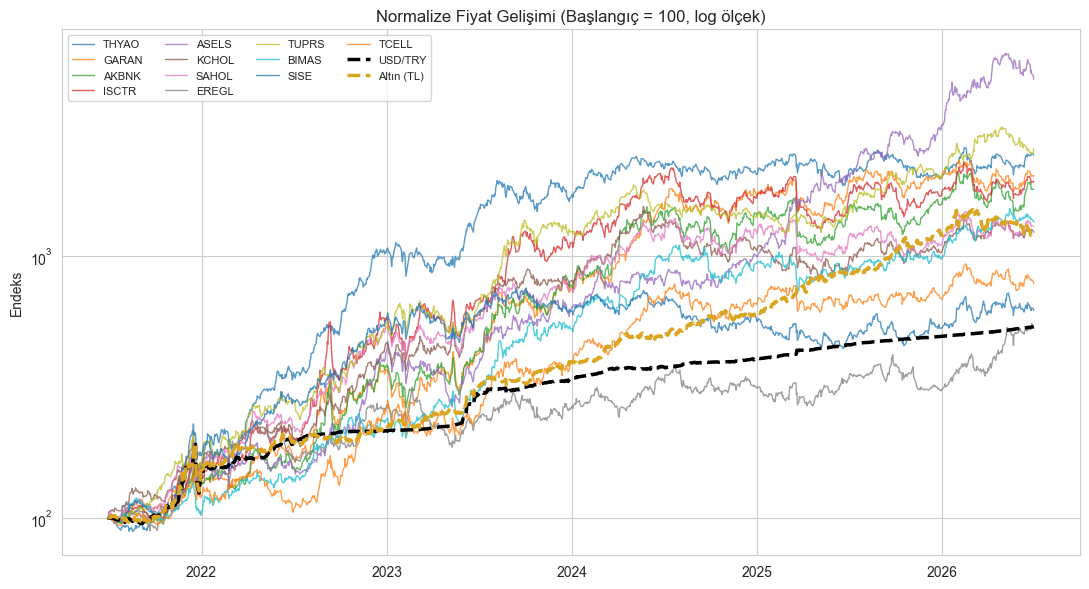

In [10]:
# Fiyat düzeyleri çok farklı (ör. ISCTR ~15 TL, ASELS ~350 TL) -> hepsini 100'e normalize et
norm = fiyatlar[HISSELER] / fiyatlar[HISSELER].iloc[0] * 100
nm = fiyatlar[["USDTRY", "ALTIN_TL"]] / fiyatlar[["USDTRY", "ALTIN_TL"]].iloc[0] * 100

fig, ax = plt.subplots()
for h in HISSELER:
    ax.plot(norm.index, norm[h], lw=1, alpha=0.75, label=h)
ax.plot(nm.index, nm["USDTRY"], lw=2.5, color="black", ls="--", label="USD/TRY")
ax.plot(nm.index, nm["ALTIN_TL"], lw=2.5, color="goldenrod", ls="--", label="Altın (TL)")
ax.set_yscale("log")   # log ölçek: yüzde değişimleri doğrusal gösterir
ax.set_title("Normalize Fiyat Gelişimi (Başlangıç = 100, log ölçek)")
ax.set_ylabel("Endeks"); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

**Yorum:** Kesikli çizgiler (dolar ve TL bazlı altın) referanstır; bir hissenin bu
çizgilerin üstünde/altında olması kur ve enflasyon karşısındaki reel performansını gösterir.

### 4.2 Getiri Korelasyon Matrisi (ısı haritası)

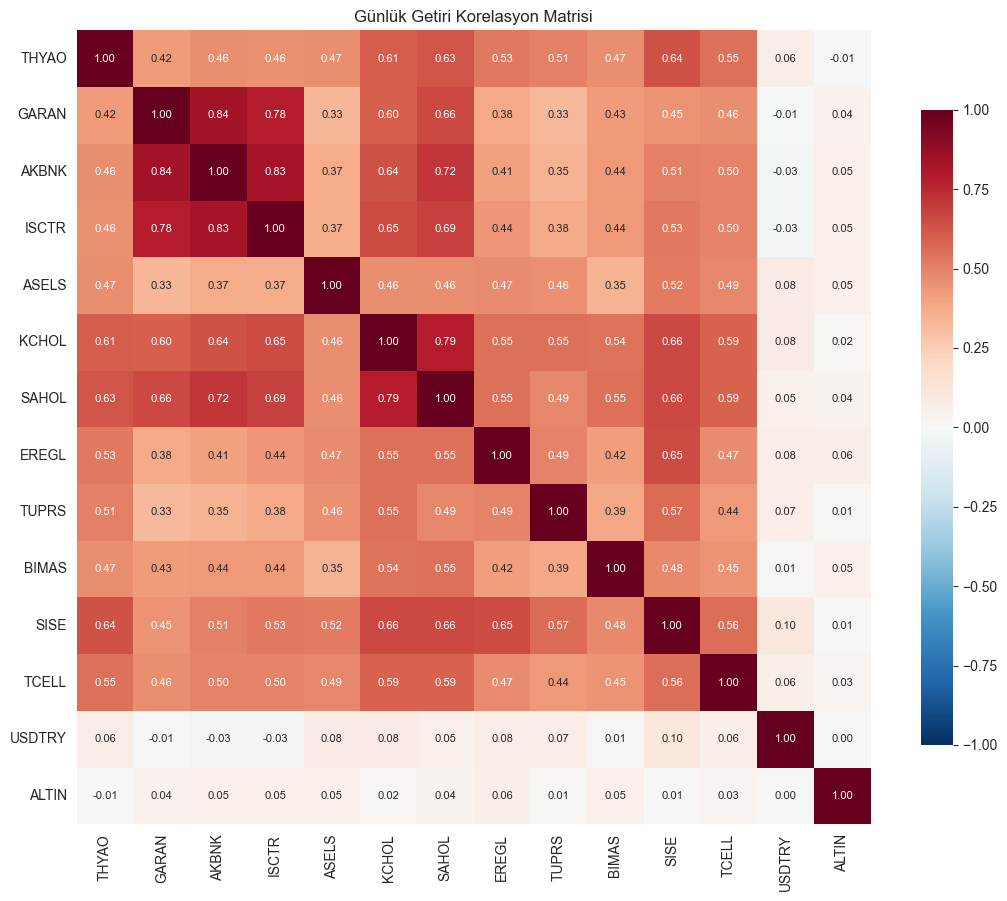

In [11]:
# Günlük getiriler arasındaki eşzamanlı doğrusal ilişki
kor = getiriler[HISSELER + ["USDTRY", "ALTIN"]].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(kor, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Günlük Getiri Korelasyon Matrisi")
plt.tight_layout(); plt.show()

**Yorum:** Bankalar kendi aralarında ~0,8 ile neredeyse tek blok gibi hareket eder.
Dolarla korelasyonlar zayıf ama pozitif (ihracatçılarda daha yüksek); altınla ilişki zayıftır.

### 4.3 Risk–Getiri Profili (saçılım grafiği)

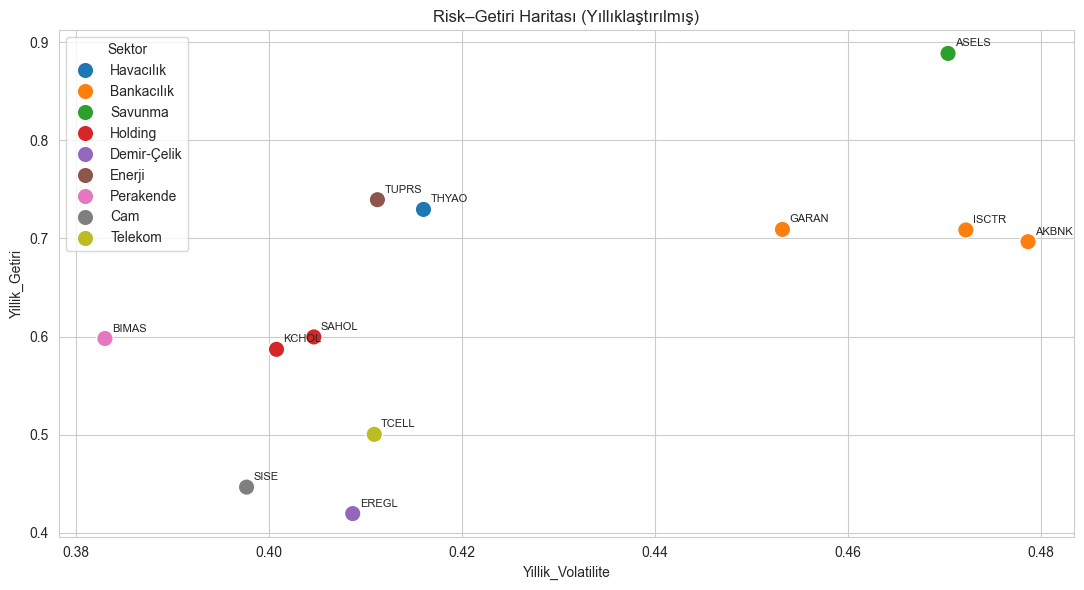

In [12]:
# Yıllıklaştırma: ortalama günlük getiri * 252; volatilite = günlük std * kök(252)
yillik_getiri = getiriler[HISSELER].mean() * 252
yillik_vol = getiriler[HISSELER].std() * np.sqrt(252)
rg = pd.DataFrame({"Yillik_Getiri": yillik_getiri, "Yillik_Volatilite": yillik_vol})
rg["Sektor"] = rg.index.map(SEKTOR)

fig, ax = plt.subplots()
sns.scatterplot(data=rg, x="Yillik_Volatilite", y="Yillik_Getiri", hue="Sektor", s=140, ax=ax)
for h in rg.index:  # her noktayı hisse koduyla etiketle
    ax.annotate(h, (rg.loc[h, "Yillik_Volatilite"], rg.loc[h, "Yillik_Getiri"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.set_title("Risk–Getiri Haritası (Yıllıklaştırılmış)")
plt.tight_layout(); plt.show()

**Yorum:** Sol üst en makbul bölgedir (düşük risk, yüksek getiri). Getiriler nominal ve
TL bazlıdır; yüksek enflasyon dönemi (2021–2026) için reel getiri çok daha düşüktür.

### 4.4 Zaman İçinde Değişen Korelasyon (yuvarlanır zaman serisi)

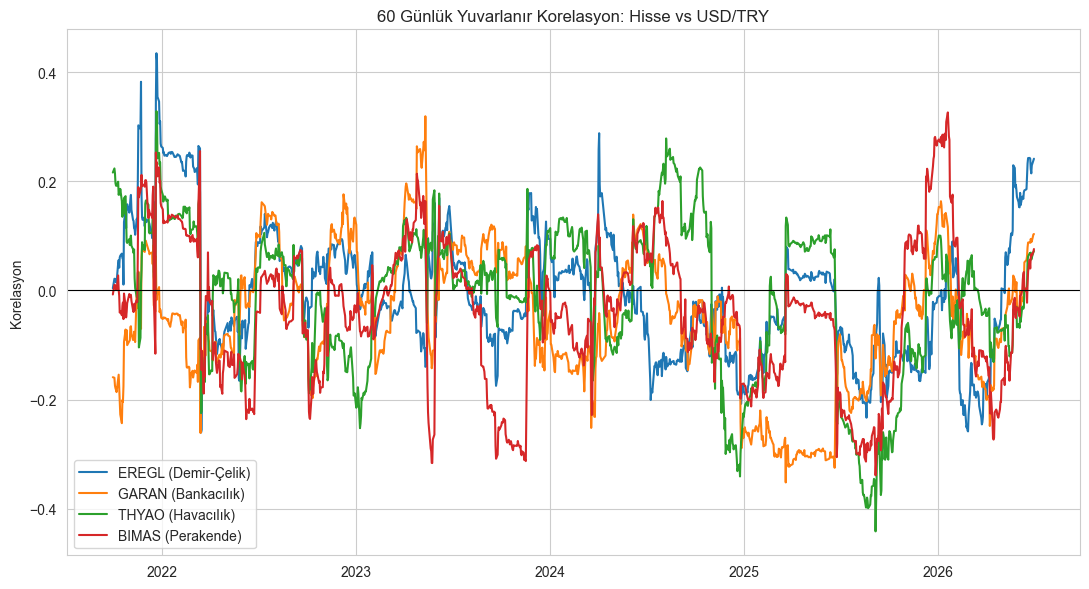

In [13]:
# 60 işlem günlük pencere ile hisse-dolar korelasyonunun zamanla değişimi
pencere = 60
ornek = ["EREGL", "GARAN", "THYAO", "BIMAS"]  # farklı sektörlerden temsilciler
fig, ax = plt.subplots()
for h in ornek:
    rc = getiriler[h].rolling(pencere).corr(getiriler["USDTRY"])
    ax.plot(rc.index, rc, lw=1.5, label=f"{h} ({SEKTOR[h]})")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"{pencere} Günlük Yuvarlanır Korelasyon: Hisse vs USD/TRY")
ax.set_ylabel("Korelasyon"); ax.legend()
plt.tight_layout(); plt.show()

**Yorum:** Korelasyon sabit değildir; çizgilerin birlikte yükseldiği dönemler dolar
şoklarının tüm piyasayı sürüklediği (çeşitlendirme faydasının azaldığı) dönemlerdir.

## 5. Modelleme ve Araştırma Sorularının Yanıtlanması

### 5.1 AS-1 — Sektör Duyarlılığı (doğrusal regresyon)

Her hisse için OLS regresyonu:
$$ R_{hisse} = \alpha + \beta_{USD} \cdot R_{USD} + \beta_{ALTIN} \cdot R_{ALTIN} + \varepsilon $$
- **β(USD):** kur %1 arttığında hissenin ortalama getiri tepkisi ("kur betası").
- **p-değeri < 0,05:** katsayı istatistiksel olarak anlamlı.
- **R²:** getirinin ne kadarının bu iki faktörle açıklandığı.

In [14]:
# Bağımsız değişkenler: dolar ve altın getirisi (+ sabit terim)
X = sm.add_constant(getiriler[["USDTRY", "ALTIN"]])

sonuclar = []
for h in HISSELER:
    model = sm.OLS(getiriler[h], X).fit()   # her hisse için ayrı regresyon
    sonuclar.append({
        "Hisse": h, "Sektor": SEKTOR[h],
        "beta_USD": model.params["USDTRY"], "p_USD": model.pvalues["USDTRY"],
        "beta_ALTIN": model.params["ALTIN"], "p_ALTIN": model.pvalues["ALTIN"],
        "R2": model.rsquared,
    })
beta_tablo = pd.DataFrame(sonuclar).set_index("Hisse").sort_values("beta_USD", ascending=False)
beta_tablo

,Sektor,beta_USD,p_USD,beta_ALTIN,p_ALTIN,R2
Hisse,,,,,,
SISE,Cam,0.2445,0.0003,0.0109,0.8572,0.0104
ASELS,Savunma,0.2302,0.0040,0.1270,0.0770,0.0091
KCHOL,Holding,0.2012,0.0032,0.0418,0.4953,0.0073
EREGL,Demir-Çelik,0.1873,0.0071,0.1366,0.0286,0.0096
TUPRS,Enerji,0.1826,0.0092,0.0225,0.7203,0.0055
THYAO,Havacılık,0.1623,0.0221,-0.0328,0.6060,0.0044
TCELL,Telekom,0.1444,0.0393,0.0602,0.3383,0.0041
SAHOL,Holding,0.1228,0.0751,0.0829,0.1806,0.0040
BIMAS,Perakende,0.0329,0.6147,0.1031,0.0791,0.0027


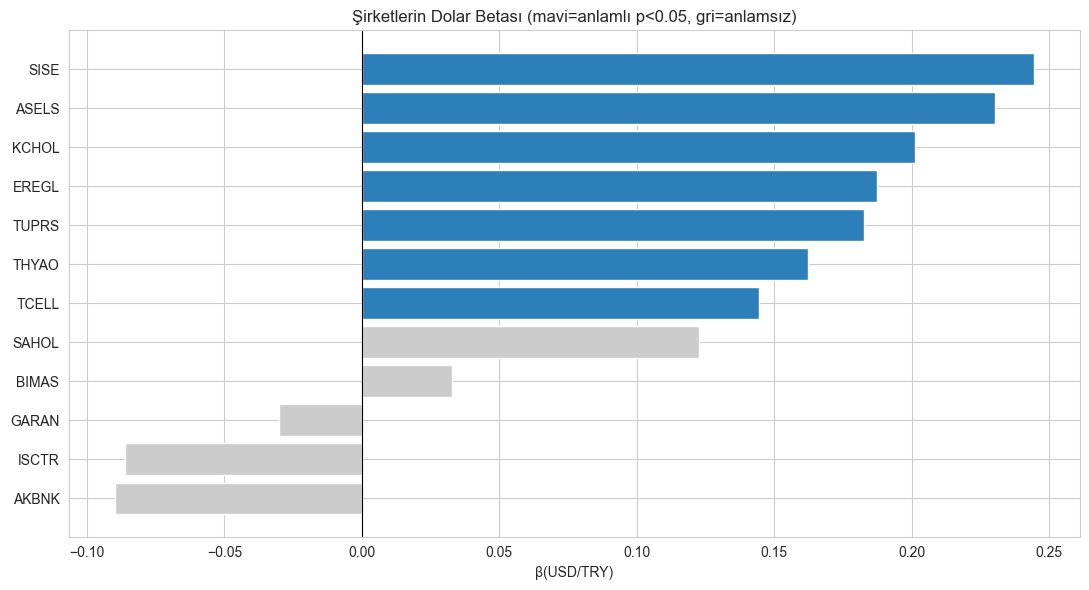

In [15]:
# Kur betalarını görselleştir; anlamlı (p<0.05) olanları renkle vurgula
bt = beta_tablo.sort_values("beta_USD")
renkler = ["#2c7fb8" if p < 0.05 else "#cccccc" for p in bt["p_USD"]]
fig, ax = plt.subplots()
ax.barh(bt.index, bt["beta_USD"], color=renkler)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Şirketlerin Dolar Betası (mavi=anlamlı p<0.05, gri=anlamsız)")
ax.set_xlabel("β(USD/TRY)")
plt.tight_layout(); plt.show()

In [16]:
# Örnek: en yüksek kur betalı hisse için tam regresyon çıktısı (katsayı, p, R²)
en_duyarli = beta_tablo["beta_USD"].idxmax()
print(f"En yüksek kur betalı hisse: {en_duyarli} ({SEKTOR[en_duyarli]})\n")
print(sm.OLS(getiriler[en_duyarli], X).fit().summary())

En yüksek kur betalı hisse: SISE (Cam)

                            OLS Regression Results                            
Dep. Variable:                   SISE   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     6.574
Date:                Fri, 03 Jul 2026   Prob (F-statistic):            0.00145
Time:                        08:35:43   Log-Likelihood:                 2839.7
No. Observations:                1249   AIC:                            -5673.
Df Residuals:                    1246   BIC:                            -5658.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

**Yanıt (AS-1):** İhracatçılar (SISE, ASELS, EREGL, TUPRS) dolara pozitif ve anlamlı
duyarlıdır; bankalar negatif ama anlamsızdır. Altın çoğunlukla anlamsız → hisseler altına
doğrudan değil kur kanalıyla dövize duyarlı. R² ≈ %1 → getirilerin çoğu şirkete özgü
faktörlerle belirlenir; amaç getiri tahmini değil, sektörel duyarlılık farkını ölçmektir.

### 5.2 AS-2 — Dolar Şoku (Aykırı) Günlerinde Ayrışma

Doların günlük getirisinin en yüksek %5'lik dilimine giren günler "dolar şoku günü"
sayılır. Bu uç günlerde ortalama getiri, normal günlerle karşılaştırılır.

In [17]:
IHRACATCI = ["SISE", "ASELS", "EREGL", "TUPRS"]   # AS-1'de pozitif+anlamlı çıkan grup
BANKA = ["GARAN", "AKBNK", "ISCTR"]

usd = getiriler["USDTRY"]
sok_esik = usd.quantile(0.95)                 # üst %5 eşik
sok = usd[usd >= sok_esik].index              # dolar şoku günleri
normal = usd[usd < sok_esik].index            # diğer günler

# Şok ve normal günlerde ortalama getiri karşılaştırması
karsilastirma = pd.DataFrame({
    "Sok_gunu_%": getiriler.loc[sok, HISSELER].mean() * 100,
    "Normal_gun_%": getiriler.loc[normal, HISSELER].mean() * 100,
})
karsilastirma["Fark_%"] = karsilastirma["Sok_gunu_%"] - karsilastirma["Normal_gun_%"]
karsilastirma["Sektor"] = karsilastirma.index.map(SEKTOR)
print(f"Dolar şoku günü sayısı (üst %5): {len(sok)}")
karsilastirma.sort_values("Sok_gunu_%", ascending=False)

Dolar şoku günü sayısı (üst %5): 63


,Sok_gunu_%,Normal_gun_%,Fark_%,Sektor
SISE,1.1664,0.1247,1.0418,Cam
THYAO,1.0492,0.2492,0.8000,Havacılık
ASELS,0.9541,0.3207,0.6334,Savunma
TUPRS,0.9367,0.2593,0.6774,Enerji
EREGL,0.8055,0.1326,0.6730,Demir-Çelik
KCHOL,0.7497,0.2055,0.5442,Holding
SAHOL,0.5556,0.2211,0.3345,Holding
TCELL,0.3215,0.1920,0.1295,Telekom
GARAN,0.1110,0.2905,-0.1795,Bankacılık
ISCTR,0.0895,0.2914,-0.2019,Bankacılık


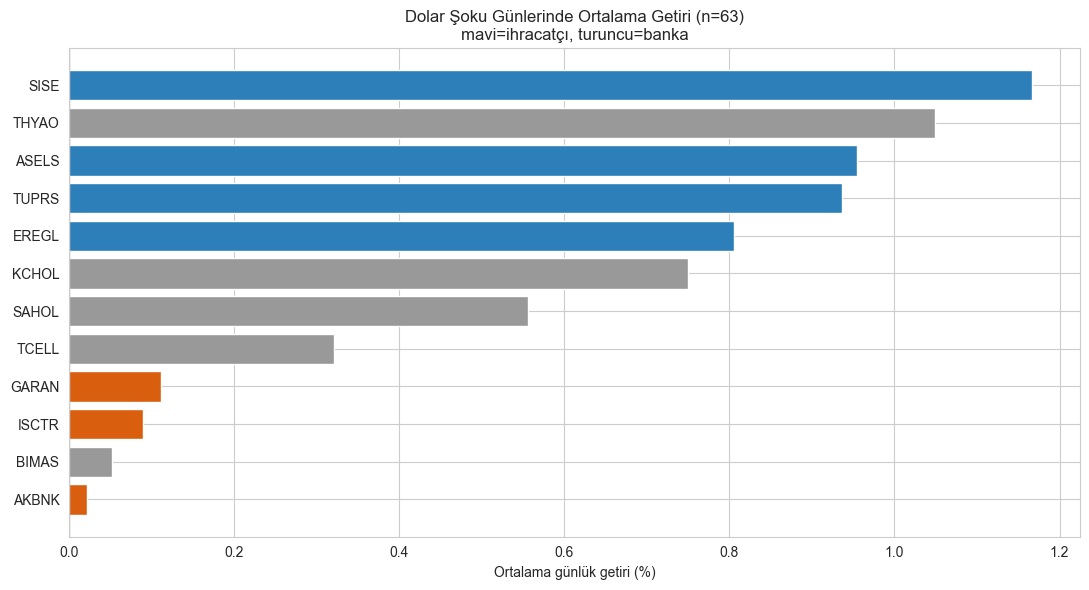

İhracatçı grup — şok: 0.97% | normal: 0.21%
Banka grup     — şok: 0.07% | normal: 0.29%


In [18]:
# Şok günlerinde ortalama getiri; ihracatçı (mavi) vs banka (turuncu) renklendirmesi
renk = {h: ("#2c7fb8" if h in IHRACATCI else ("#d95f0e" if h in BANKA else "#999999")) for h in HISSELER}
srt = (getiriler.loc[sok, HISSELER].mean() * 100).sort_values()
fig, ax = plt.subplots()
ax.barh(srt.index, srt.values, color=[renk[h] for h in srt.index])
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Dolar Şoku Günlerinde Ortalama Getiri (n={len(sok)})\nmavi=ihracatçı, turuncu=banka")
ax.set_xlabel("Ortalama günlük getiri (%)")
plt.tight_layout(); plt.show()

print(f"İhracatçı grup — şok: {getiriler.loc[sok, IHRACATCI].mean().mean()*100:.2f}% | "
      f"normal: {getiriler.loc[normal, IHRACATCI].mean().mean()*100:.2f}%")
print(f"Banka grup     — şok: {getiriler.loc[sok, BANKA].mean().mean()*100:.2f}% | "
      f"normal: {getiriler.loc[normal, BANKA].mean().mean()*100:.2f}%")

**Yanıt (AS-2):** Şok günlerinde ihracatçılar belirgin şekilde pozitif ayrışır;
bankalar normal günlerinin bile gerisinde kalır. AS-1'deki regresyon bulgusu uç günlerde
daha da güçlenir.

### 5.3 AS-3 — Öncülük / Gecikmeli İlişki

Dolar ile hisse getirisi arasında –5..+5 iş günü gecikmeli çapraz korelasyon.
`k>0` doların, `k<0` hissenin öncülüğünü, `k=0` eşzamanlı ilişkiyi gösterir.

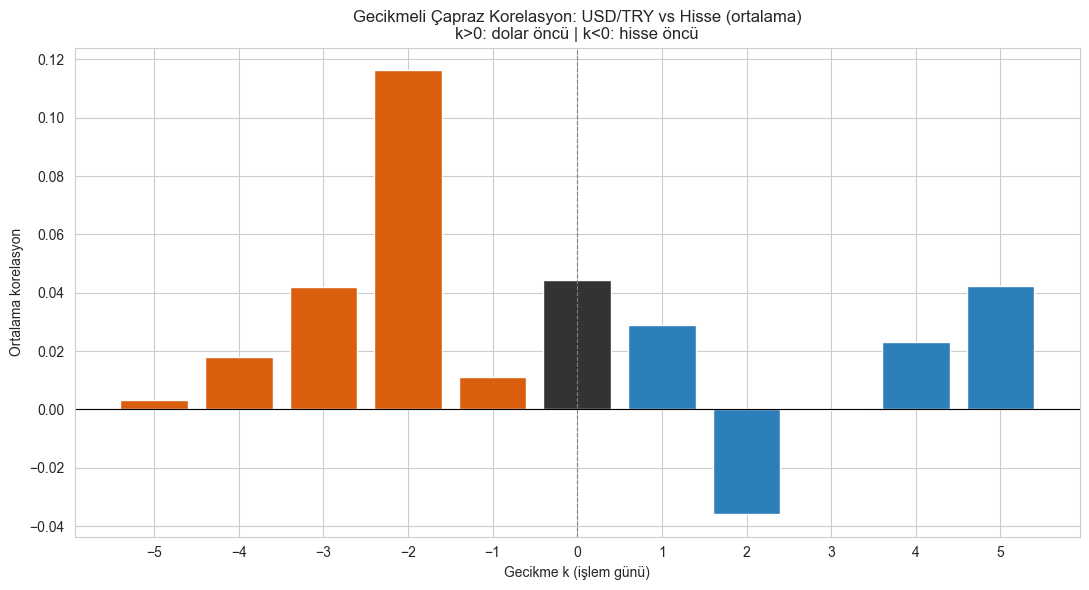

Eşzamanlı (k=0) korelasyon: 0.044


In [19]:
laglar = range(-5, 6)
lag_mat = pd.DataFrame(index=list(laglar), columns=HISSELER, dtype=float)
for h in HISSELER:
    for k in laglar:
        # corr(USDTRY_t, Hisse_{t+k}); shift(-k) hisseyi k gün kaydırır
        lag_mat.loc[k, h] = usd.corr(getiriler[h].shift(-k))
lag_ort = lag_mat.mean(axis=1)   # 12 hissenin ortalaması

fig, ax = plt.subplots()
ax.bar(lag_ort.index, lag_ort.values,
       color=["#d95f0e" if k < 0 else ("#2c7fb8" if k > 0 else "#333333") for k in lag_ort.index])
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_title("Gecikmeli Çapraz Korelasyon: USD/TRY vs Hisse (ortalama)\nk>0: dolar öncü | k<0: hisse öncü")
ax.set_xlabel("Gecikme k (işlem günü)"); ax.set_ylabel("Ortalama korelasyon")
ax.set_xticks(list(laglar)); plt.tight_layout(); plt.show()
print(f"Eşzamanlı (k=0) korelasyon: {lag_ort[0]:.3f}")

**Yanıt (AS-3):** Tüm gecikmelerde korelasyon zayıftır (|·| < 0,12) ve eşzamanlı değer
düşüktür. Ne dolar ne hisse diğerini güçlü biçimde öncelemez; ilişki büyük ölçüde eşzamanlı
ve zayıftır — kısa vadede piyasanın görece etkin çalıştığına işaret eder.

## 6. Sonuç ve Bulgular

- **AS-1:** İhracat ağırlıklı sektörler dolara pozitif ve anlamlı duyarlı; bankalar
  tepkisiz/negatif (anlamsız). Altın etkisi zayıf → duyarlılık kur kanalıyla oluşur.
- **AS-2:** Dolar şoku günlerinde ihracatçı–banka ayrışması en yüksek seviyeye çıkar.
- **AS-3:** Günlük ölçekte dolar ile borsa arasında güçlü bir öncülük ilişkisi yoktur;
  ilişki eşzamanlı ve zayıftır.

**Genel yorum:** BIST blue-chip şirketlerinin dolar duyarlılığı sektöre göre anlamlı biçimde
farklılaşır; ancak kurun günlük getirileri açıklama gücü sınırlıdır (R² ≈ %1). Bu, tek
faktörlü "kur her şeyi belirler" yaklaşımının yanıltıcı olduğunu gösterir.

**Sınırlılıklar:** Eşzamanlı ve doğrusal ilişki ölçülür; korelasyon/regresyon nedensellik
kanıtlamaz. Örneklem 2021–2026 yüksek enflasyon dönemini kapsar; bulgular bu bağlama özgüdür.